# 確率と確率分布



## 条件付き確率

事象の確率を、他の事象が起こったことを前提にして求めることを条件付き確率(conditional probability)という。
もちろん、それぞれの事象が独立であれば、条件付き確率は単純にその事象の確率(の積)で表現できるが、一般の場合は必ずしも事象が独立であるとは限らない。

例えば、$A$と$B$という2つの事象があるとき、$A$が起こったという条件の下で$B$が起こる確率は、$P(B|A)$と表される。このとき、$P(B|A)$は$P(A)$と$P(B)$の積ではなく、$A$が起こったときの$B$の起こりやすさを考慮した確率である。

例としてある集団の50%が身長160cm以上であるとする。一方、この集団は50%が60kg以上の体重を持つとする。
このとき、ランダムに選んだ人が身長160cm以上である確率($P(A)$としよう)は50%であり、体重60kg以上である確率$P(B)$も50%である。

もし、身長と体重が完全に独立であれば、身長160cm以上で体重60kg以上である確率$P(A, B)$は$P(A) \times P(B) = 0.5 \times 0.5 = 0.25$となる。
しかし、身長と体重は正の相関を持つことが多く、実際の$P(A, B)$は0.25よりも大きくなることが一般的でろう。

このような場合、$P(A,B) \neq P(A) \times P(B)$となる。
このとき、条件付き確率は次のように定義される。

$$
P(B|A) = \frac{P(A,B)}{P(A)}
$$

この式は、$A$が起こったときの$B$の起こりやすさを表している。
同様に、$P(A|B)$は次のように定義される

$$
P(A|B) = \frac{P(A,B)}{P(B)}
$$

このように、条件付き確率は事象の依存関係を考慮して確率を計算するための重要な概念である。

### ベイズの定理

ベイズの定理(Bayes' theorem)は、条件付き確率を用いて事象の確率を更新するための重要な法則である。
ベイズの定理は、次のように表される。

`````{admonition} 定義: ベイズの定理
:class: note

$$
P(A|B) = \frac{P(B|A) P(A)}{P(B)}
$$

`````

この式は、事象$B$が起こったときに事象$A$が起こる確率を、事象$A$が起こったときの事象$B$の確率と、事象$A$の確率、および事象$B$の確率を用いて計算する方法を示している。
なんのことはない、これは条件付き確率の定義そのものである。

一方で、ベイズの定理の有用性を示すために、医療分野での応用を例に考えてみよう。

ある病気の検査があり、その検査は病気にかかっている人の90%を正しく検出し、病気にかかっていない人の95%を正しく陰性と判定するものとする。

このとき、検査結果が陽性であった場合に実際に病気にかかっている確率を求めることができる。
ここで、次のような情報が与えられているとする。

- 病気にかかっている人の割合（事前確率）: $P(A) = 0.01$（1%）
- 病気が検査で陽性と判定される確率（事後確率）: $P(B|A) = 0.9$（病気にかかっている人の90%が陽性と判定される; 真陽性）
- 病気にかかっていない人が陽性と判定される確率: $P(B|\neg A) = 0.05$（病気にかかっていない人の5%が陽性と判定される; 偽陽性）
- 検査が陽性である確率: $P(B) = P(B|A) P(A) + P(B|\neg A) P(\neg A)$

したがって $A$は「病気にかかっている」という事象、$B$は「検査が陽性である」という事象に対応している。

このとき、ベイズの定理を用いて、検査結果が陽性であった場合に実際に病気にかかっている確率$P(A|B)$を求めることができる。

$$
P(A|B) = \frac{P(B|A) P(A)}{P(B)} = \frac{0.9 \times 0.01}{0.9 \times 0.01 + 0.05 \times 0.99}
 \approx 0.154
$$

## 視覚的なイメージ

あるデータが２つの変数によって特徴づけられるとき、一方のデータが決まると、もう一方のデータもある程度決まることがある。

$$
y(x_1, x_2) = sin(2\pi x_1) sin(2\pi x_2)
$$

という関数のyの値を適当なメッシュ点で計算してみると次のような図が得られる。

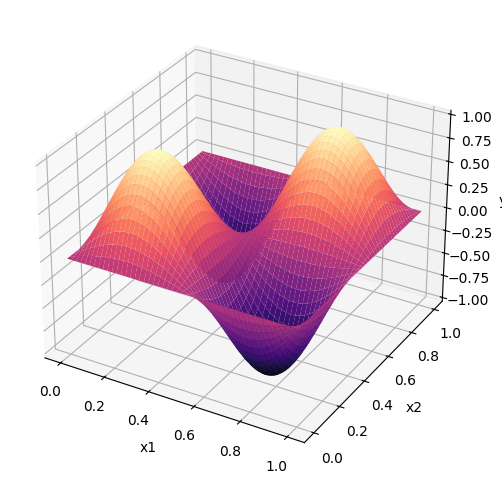

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def y(x1, x2):
    return np.sin(2*np.pi*x1) * np.sin(2*np.pi*x2)

xymesh = np.meshgrid(np.linspace(0, 1, 100), np.linspace(0, 1, 100))
zmesh = y(xymesh[0], xymesh[1])
# 3D plot
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xymesh[0], xymesh[1], zmesh, cmap='magma')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y')
plt.show()
plt.close() 


このとき、$x_1 \in [0, 1]$と$x_2 \in [0, 1]$の範囲で適当な点を50点ほどサンプルして、対応する$y$の値に僅かなノイズ(観測/測定の誤差だと考えてよい)を加えてプロットしてみると...

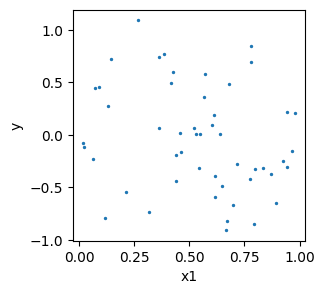

In [3]:
num_samples = 50
np.random.seed(0)
x1_samples = np.random.rand(num_samples)
x2_samples = np.random.rand(num_samples)
y_samples = y(x1_samples, x2_samples) + np.random.normal(0, 0.1, num_samples)

plt.figure(figsize=(3, 3))
plt.scatter(x1_samples, y_samples, s=2)
plt.xlabel('x1')
plt.ylabel('y')
plt.show()

正解を知っていればうっすらとその関数の形が見えるが、判然としない。

一方で、$x_2$が特定の値、例えば$x_2 = \pi/4$のとき、また$x_1$を無作為にサンプルして、$y$の値をプロットしてみると、データの背後にある関数の形がはっきりと見える事がわかる。

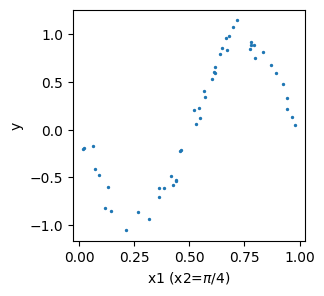

In [4]:
num_samples = 50
np.random.seed(0)
x1_samples = np.random.rand(num_samples)
y_samples = y(x1_samples, np.pi/4) + np.random.normal(0, 0.1, num_samples)

plt.figure(figsize=(3, 3))
plt.scatter(x1_samples, y_samples, s=2)
plt.xlabel("x1 (x2=$\\pi$/4)")
plt.ylabel('y')
plt.show()

このように、$x2$が決まらないと、$y$の値もばらついてしまうが、$x2$が特定の値に固定されると、$y$の値もある程度決まることがわかる。
このような関係を、条件付き確率の概念を用いて表現することができる。

## 確率密度関数

上の確率の導入では事象が離散的に起こる場合を考えた。
以下では、実数値を取る連続型確率変数(continuous random variable)について考えることにする。

関数$f: \mathbb{R}^D \to \mathbb{R}$が確率密度関数(probability density function; pdf)であるとは、次を満たすことをいう。

1. $f(\mathbf{x}) \geq 0$ である。
2. 全ての値に対する$f$の積分は1である。

$$
\int_{\mathbb{R}^D} f(\mathbf{x}) \, d\mathbf{x} = 1
$$

ここから、連続型確率変数$X$が

$$
P( a \leq X \leq b ) = \int_{a}^{b} f(x) \, dx
$$

を満たすことがわかる。確率変数$X$が微小区間$[x, x+dx]$に入る確率は$\simeq f(x)dx$であることから、$f(x)$が確率密度と呼ばれることも理解できる。

連続型確率変数$X$の累積分布関数(cumulative distribution function; cdf)は、次のように定義される。

$$
F_X(\mathbf{x}) = P(X_1 \leq x_1, X_2 \leq x_2, \ldots, X_D \leq x_D) = \int_{-\infty}^{x_1} \int_{-\infty}^{x_2} \cdots \int_{-\infty}^{x_D} f(\mathbf{x}) \, dx_1 \, dx_2 \cdots dx_D
$$


次に、確率変数$X$の期待値(expectation)と分散(variance)を定義する。

期待値は、確率変数$X$の取り得る値にその確率を重み付けして合計したもので、次のように定義される。

$$
E[X] = \int_{-\infty}^{\infty} x f(x) \, dx
$$

分散は、確率変数$X$の値が期待値からどれだけ散らばっているかを示す指標で、次のように定義される。

$$
\text{Var}[X] = E[(X - E[X])^2] = \int_{-\infty}^{\infty} (x - E[X])^2 f(x) \, dx
$$

確率密度関数を明示する $E_f[X]$といった表記もあるが、ここでは単に$E[X]$と書くことにした。


## ガウス分布

ガウス分布(Gaussian distribution)は、確率密度関数が次の形を持つ確率分布である。
単変量の場合と多変量の場合をそれぞれ定義しておく:

`````{admonition} 定義: ガウス分布/正規分布
:class: note

一次元・多次元のガウス分布はそれぞれ以下のように定義される。

$$
\begin{align*}
f(x) & = \frac{1}{\sqrt{2 \pi \sigma^2}} \exp\left(-\frac{(x - \mu)^2}{2 \sigma^2}\right) \\
f(\mathbf{x}) & = \frac{1}{\sqrt{ (2\pi)^D |\Sigma|}} \exp\left(-\frac{1}{2} (\mathbf{x} - \boldsymbol{\mu})^T \Sigma^{-1} (\mathbf{x} - \boldsymbol{\mu})\right) 
\end{align*}
$$

`````



指数関数の前にある係数は、確率密度関数が正規化されていることを保証するためのもので、ガウス分布を全空間で積分したときに１になるようになっている。
1変数の場合のガウス積分の簡単な証明を与えておこう。

$$
\begin{align*}
I &\equiv \int_{-\infty}^{\infty} e^{(-\alpha x^2)} dx \\
I^2 & = \left( \int_{-\infty}^{\infty} e^{-\alpha x^2} dx \right) \left( \int_{-\infty}^{\infty} e^{-\alpha y^2} dy \right) \\
& = \int_{-\infty}^{\infty} \int_{-\infty}^{\infty} e^{-\alpha (x^2 + y^2)} dx dy \\
& = \int_{0}^{2\pi} \int_{0}^{\infty} e^{-\alpha r^2} r dr d\theta \\
& = 2\pi \left[ -\frac{1}{2\alpha} e^{-\alpha r^2} \right]_{0}^{\infty} \\
I & = \sqrt{\frac{\pi}{\alpha}} 
\end{align*}
$$

$x=r \cos \theta, y=r \sin \theta$と置換して、極座標に変換した。Jacobianは$r$である。
$\alpha=1/(2\sigma^2)$と置換すると、ガウス分布の正規化定数が得られる。





以下では、多次元正規分布(ガウス分布)の数学的に優れた性質について説明する。
時折、具体例として2次元の正規分布を考えるので、ここで絵を作っておこう。

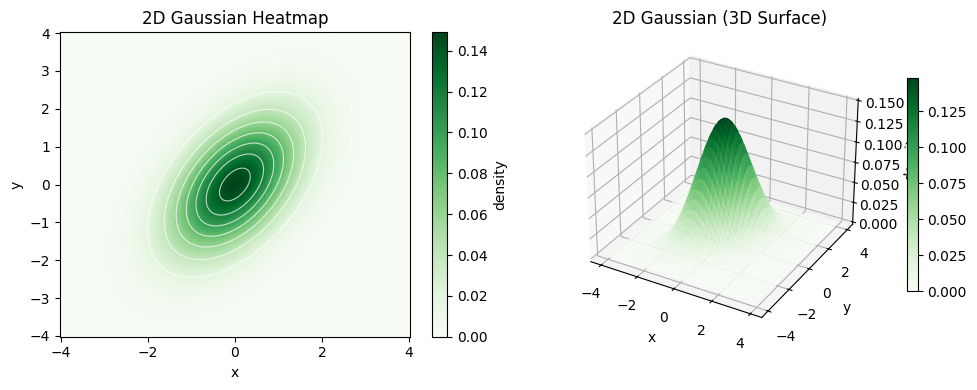

In [ ]:
# 2次元正規分布の可視化
mu = np.array([0.0, 0.0])
Sigma = np.array([[1.0, 0.6],
                  [0.6, 1.5]])

# グリッド作成
x = np.linspace(-4, 4, 200)
y = np.linspace(-4, 4, 200)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))

# 2次元ガウス分布の密度
Sigma_inv = np.linalg.inv(Sigma)
Sigma_det = np.linalg.det(Sigma)
norm = 1.0 / (2 * np.pi * np.sqrt(Sigma_det))

diff = pos - mu
Z = norm * np.exp(-0.5 * np.einsum('...i,ij,...j->...', diff, Sigma_inv, diff))

# 横並びで描画
fig = plt.figure(figsize=(10, 4))

# ヒートマップ
ax1 = fig.add_subplot(1, 2, 1)
hm = ax1.pcolormesh(X, Y, Z, shading='auto', cmap='Greens')
ax1.contour(X, Y, Z, colors='white', linewidths=0.8, alpha=0.7)
ax1.set_title('2D Gaussian Heatmap')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
fig.colorbar(hm, ax=ax1, label='density')

# 3D
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf = ax2.plot_surface(X, Y, Z, cmap='Greens', linewidth=0, antialiased=True)
ax2.set_title('2D Gaussian (3D Surface)')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('density')
fig.colorbar(surf, ax=ax2, shrink=0.7, pad=0.08)

plt.tight_layout()
plt.show()


変数を２つに分けて、それらの **同時分布(joint distribution)** がガウス分布であるとみなすこともできる。

$$
p(\mathbf{x}, \mathbf{y}) = \mathcal{N}\left(
    \begin{bmatrix}
        \mathbf{\mu}_x \\
        \mathbf{\mu}_y
    \end{bmatrix},
    \begin{bmatrix}
        \Sigma_{xx} & \Sigma_{xy} \\
        \Sigma_{yx} & \Sigma_{yy}
    \end{bmatrix}
\right) 
$$

このとき**周辺分布(marginal distribution)**(特定の変数の積分を取ることで得られる分布)と条件付き分布もまたガウス分布になる性質がある。$\mathbf{y}$について周辺化した分布は、

$$
\begin{align*}
\int d\mathbf{y} p(\mathbf{x}, \mathbf{y}) 
& = \mathcal{N}\left( \mathbf{\mu}_{x}, \Sigma_{xx} \right)
\end{align*}
$$

条件付き分布は次のようになる。

$$
\begin{align*}
p(\mathbf{x} | \mathbf{y}) & = \mathcal{N}\left(
    \mathbf{\mu}_{x|y},
    \Sigma_{x|y}\right) \\
\mathbf{\mu}_{x|y} & = \mathbf{\mu}_x + \Sigma_{xy} \Sigma_{yy}^{-1} (\mathbf{y} - \mathbf{\mu}_y) \\
\Sigma_{x|y} & = \Sigma_{xx} - \Sigma_{xy} \Sigma_{yy}^{-1} \Sigma_{yx}
\end{align*}
$$

以下では、条件分布の式の導出を紹介しよう:

ある行列$M$の逆行列が以下のように書けるとき

$$
\begin{align*}
M & = \left( 
\begin{matrix}
A & B \\
C & D
\end{matrix}
\right)^{-1} \\
\end{align*}
$$

$$
S \equiv (A - B D^{-1} C)^{-1}
$$

で定義される行列$S$を用いて、$M$は以下のように表される:

$$
M = \begin{pmatrix}
S & -S B D^{-1} \\
-D^{-1} C S & D^{-1} + D^{-1} C S B D^{-1}
\end{pmatrix}
$$

なお、$S^{-1}$は行列$M$のSchur補行列(Schur complement)と呼ばれる。

上記の関係を用いて、共分散行列の逆行列を、分割したそれぞれの部分行列の逆行列で表現することにする。

$$
\begin{align*}
\Sigma^{-1} & \equiv
\left( 
\begin{matrix}
\Sigma_{xx} & \Sigma_{xy} \\
\Sigma_{yx} & \Sigma_{yy}
\end{matrix}
\right)^{-1} \equiv \begin{pmatrix}
\Lambda_{xx} & \Lambda_{xy} \\
\Lambda_{yx} & \Lambda_{yy}
\end{pmatrix} 
\end{align*}
$$

共分散行列の逆行列を精度行列(precision matrix)と呼び、$\Lambda$で表す慣例に倣った。

確率分布に係る係数等は一旦忘れて、条件付き確率分布のexponential関数の中身を見ていく。

$$
\begin{align*}
\log P(\mathbf{x}, \mathbf{y}) 
=& -\frac{1}{2} (\mathbf{x} - \boldsymbol{\mu}_x)^T \Lambda_{xx} (\mathbf{x} - \boldsymbol{\mu}_x) -\frac{1}{2} (\mathbf{x} - \boldsymbol{\mu}_x)^T \Lambda_{xy} (\mathbf{y} - \boldsymbol{\mu}_y) \\
& -\frac{1}{2} (\mathbf{y} - \boldsymbol{\mu}_y)^T \Lambda_{yx} (\mathbf{x} - \boldsymbol{\mu}_x) 
-\frac{1}{2} (\mathbf{y} - \boldsymbol{\mu}_y)^T \Lambda_{yy} (\mathbf{y} - \boldsymbol{\mu}_y) + \text{const.} 
\end{align*}
$$

$\mathbf{x}$に関する1・2次の項をまとめよう。

$$
\begin{align*}
-\frac{1}{2} \mathbf{x}^T \Lambda_{xx} \mathbf{x} 
+ \mathbf{x}^T (\Lambda_{xx} \boldsymbol{\mu}_x - \Lambda_{xy} (\mathbf{y} - \boldsymbol{\mu}_y) )
\end{align*}
$$

ここで、$\Lambda_{xy} = \Lambda_{yx}^T$であることを用いた。

さらに、

$$
\begin{align*}
\Lambda_{xx} &= (\Sigma_{xx} - \Sigma_{xy} \Sigma_{yy}^{-1} \Sigma_{yx})^{-1} = \Sigma_{x|y}^{-1}\\
\Lambda_{xy} &= -\Sigma_{x|y}^{-1} \Sigma_{xy} \Sigma_{yy}^{-1}
\end{align*}
$$

から、

$$
\begin{align*}
\log P(\mathbf{x} | \mathbf{y}) &= -\frac{1}{2} (\mathbf{x} - \boldsymbol{\mu}_{x|y})^T \Sigma_{x|y}^{-1} (\mathbf{x} - \boldsymbol{\mu}_{x|y}) + \text{const.}
\end{align*}
$$

となる。正規化すると、条件確率が上のガウス分布になることがわかる。
ここでは、対称可逆な行列に対する下記の性質を用いた。

`````{admonition} 行列・ベクトルの平方完成
:class: tip

行列版の平方完成と言える。

$$
-\frac{1}{2} \mathbf{x}^T A \mathbf{x} + \mathbf{x}^T \mathbf{b} = -\frac{1}{2} (\mathbf{x} - A^{-1} \mathbf{b})^T A (\mathbf{x} - A^{-1} \mathbf{b}) + \frac{1}{2} \mathbf{b}^T A^{-1} \mathbf{b}
$$

右辺第2項は定数項なので、確率分布の正規化には影響しない。
`````

`````{admonition} 問題
:class: attention

上記の式が成り立つことをチェックせよ。
右辺を展開して、左辺に等しいことを示せば良い。

`````

`````{admonition} 問題
:class: attention

独立な正規分布に従う2つの確率変数

$$
\begin{align*}
\mathbf{x} & \sim \mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\Sigma_1}) \\
\mathbf{y} & \sim \mathcal{N}(\boldsymbol{\mu}_2, \boldsymbol{\Sigma_2}) 
\end{align*}
$$

があるとき、$\mathbf{x}$と$\mathbf{y}$の和$\mathbf{z} = \mathbf{x} + \mathbf{y}$が正規分布に従うことを示し、その平均ベクトル・共分散行列を、元の分布のパラメータを用いて表せ。

`````

## ガウス分布と機械学習の関係

機械学習分野において、ガウス分布は非常に重要な役割を果たす。
全てを列挙することはできないが、幾つか代表的な例を挙げておく。

- **線形回帰**: 線形回帰では、目的変数がガウス分布に従うと仮定することが多い。これは、誤差項がガウス分布に従うと仮定することで、線形モデルのパラメータを推定するだけでなく予測の信頼区間(不確実性)を計算できる。
- **ガウス過程**: ガウス過程は、関数の分布を多次元正規分布で表現する手法であり、非線形回帰や分類問題において強力なツールとなる。ガウス過程は、データ点間の相関を考慮し、予測の不確実性を定量化することができ、ベイズ最適化などメタ的なアプローチにおいても利用される。
- **混合ガウス分布**: 混合ガウス分布は、複数のガウス分布の線形結合であり、クラスタリングや密度推定に利用される。特に、Gaussian Mixture Model (GMM)は、データが複数の異なるガウス分布から生成されていると仮定し、各クラスタのパラメータを推定するために使用される。
- **変分オートエンコーダ**: 変分オートエンコーダ(VAE)は、潜在変数モデルの一種であり、潜在変数がガウス分布に従うと仮定することで、データの生成過程を学習することが多い。
- **拡散モデル**: 拡散モデルは、データの生成過程を逆拡散過程としてモデル化する手法であり、特に画像生成タスクにおいて注目されている。拡散モデルは、データにノイズを加えながら生成過程を学習し、最終的に高品質なサンプルを生成することができる。

上記のうちのいくつかは、この資料でも説明してあるので適宜参照のこと。

## 確率分布のベイズ推定

2つの確率変数の同時分布を $p(\mathbf{x}, \mathbf{y})$、
$p(\mathbf{x}), p(\mathbf{y})$ はそれぞれの確率変数の周辺分布と呼ぶ。

確率の和の規則により、

$$
p(\mathbf{x}) = \int p(\mathbf{x}, \mathbf{y}) d\mathbf{y}
$$

$$
p(\mathbf{y}) = \int p(\mathbf{x}, \mathbf{y}) d\mathbf{x}
$$

が成り立つ。離散的な場合は積分を和に置き換えればよい。

また積の規則と呼ばれる法則は、同時分布と条件付き分布を結びつける:

$$
p(\mathbf{x}, \mathbf{y}) = p(\mathbf{x} | \mathbf{y}) p(\mathbf{y}) = p(\mathbf{y} | \mathbf{x}) p(\mathbf{x})
$$

ここから確率分布に対するベイズの定理が導かれる:

$$
p(\mathbf{x} | \mathbf{y}) = \frac{p(\mathbf{y} | \mathbf{x}) p(\mathbf{x})}{p(\mathbf{y})}
$$

特に、$p(\mathbf{x})$を事前分布(prior distribution)、$p(\mathbf{y} | \mathbf{x})$を尤度(likelihood)、$p(\mathbf{x} | \mathbf{y})$を事後分布(posterior distribution)と呼ぶ。

確率変数を$x, y$とかくと、なんとなく等価・類似性のある量を２つ並べたように見えるが、もう少し機械学習の文脈に即した例を考えてみよう。

いま何らかの現象やデータを説明することを目的に何らかのパラメータを持つモデル(ニューラルネットワークなど)を考え、
さらにそのモデルのパラメータを$\mathbf{\theta}$という変数で表すことにする。
このとき、入力データを$\mathbf{x}$、出力データを$\mathbf{y}$とし、幾つかのデータ点 $D = \{(\mathbf{x}_i, \mathbf{y}_i)\}_{i=1}^N$が得られていたとする。

決められたデータセットに対して、最適なパラメータ$\mathbf{\theta}$を求めることが最適化問題の主要な目的であるが、
いま考えているパラメータ$\mathbf{\theta}$がどのような値を取るかは不確実であり、確率変数として扱い分布を考えることもできる。
その利点は、パラメータの不確実性を考慮に入れることで、より堅牢なモデルを構築できる点にある。
さて、パラメータをある次元の特定の値ではなく、確率分布として扱うとき、次のような確率分布を考えることができる:

$$
p(\mathbf{\theta} | D) \propto p(D | \mathbf{\theta}) p(\mathbf{\theta})
$$

左辺の$p(\mathbf{\theta} | D)$は、与えられたデータ$D$に基づくパラメータ$\mathbf{\theta}$の **事後分布(posterior)** を表す。
右辺の$p(D | \mathbf{\theta})$は、パラメータ$\mathbf{\theta}$が与えられたときのデータ$D$の **尤度(likelihood)** を表し、$p(\mathbf{\theta})$はパラメータ$\mathbf{\theta}$の **事前分布(prior)** を表す。
上記の比例関係の式から、パラメータに対する事前分布(事前知識や仮定)を、観測したデータに基づいて更新することができる。

この文脈での尤度は、モデルがデータをどれだけよく説明できるかを示す指標であり、例えば、回帰問題であれば、観測データとモデルの平均二乗誤差を基にしたガウス分布を用いることも多い。

$$
p(D | \mathbf{\theta}) =C \exp\left(-\frac{1}{2\sigma^2} \sum_{i=1}^N ||\mathbf{y}_i - f(\mathbf{x}_i; \mathbf{\theta})||^2 \right)
$$

$C$は正規化定数である。

また、上ではあえて比例関係$\propto$を用いたが、分母にあたる$p(D)$はデータ$D$に関する正規化定数であり、パラメータ$\mathbf{\theta}$に依存しないため、事後分布を計算する際には無視できる(というより、計算が非常に難しいことが多い)ことによる。

### $\clubsuit$ 事後分布からのサンプリング

事後分布に従うサンプルを生成するための方法としては、大別すると、近似推論(≒事後分布を性質の良い分布で近似する)と、MCMC(Markov Chain Monte Carlo; マルコフ連鎖モンテカルロ法)がある。
事前分布及び尤度を性質の良い(共役分布; conjugate distribution)で選ぶと、事後分布も特定の分布族に属することが保証され、解析的に計算できる場合がある。
近似推論では、こうした仮定を積極的に用いて、事後分布を計算しやすい分布で近似する。

一方で、MCMCは、事後分布からのサンプルを生成するための確率的なアルゴリズムであり、事後分布の形状に関する仮定を必要としない。
十分に多くのサンプルを"きちんと"生成できれば、事後分布を反映したサンプルを得ることができるが、実際にはサンプルの自己相関や収束性などに注意が必要であり、適切なアルゴリズムの選択とパラメータ設定が重要である。
とくに多次元の分布からサンプルを生成する場合は、サンプルの自己相関が高くなりやすく、効率的なサンプリングが難しいことが多い。
代表的なMCMCアルゴリズムには以下のようなものがある:

- ギブスサンプリング(Gibbs sampling): 各変数を順番に更新する方法。条件付き分布が計算しやすい場合に有効。
- メトロポリス・ヘイスティングス法(Metropolis-Hastings): 提案分布から新しいサンプルを生成し、受け入れるかどうかを確率的に決定する方法。提案分布の選択が重要。
- ハミルトニアンモンテカルロ(Hamiltonian Monte Carlo; HMC): 物理学のハミルトン力学に基づく方法で、効率的に高次元空間を探索できる。勾配情報を利用するため、計算コストが高い場合がある。
- レプリカ交換法(Replica Exchange MCMC; REMC) あるいはparallel tempering: 複数のマルコフ連鎖を異なるスケール因子(温度とも呼ばれる)で滑らかにしながら、レプリカ間でサンプルを交換する方法。多峰性分布のサンプリングに有効。
- Affine Invariant MCMC: 複数のサンプルを同時に更新する方法で、アフィン変換に対して不変な性質を持つ。高次元空間でのサンプリングに適している。特に並列性が優れているほか、職人芸による提案分布の調整が不要であることが利点である。
最初に提案されたのは Goodman & Weare (2010) で、天文学の分野で広く用いられているemcee (Foreman-Mackey et al., 2013) はこのアルゴリズムを実装したPythonライブラリである。

筆者自身も、大学院生の頃〜大学教員になりたての頃に、物理学の文脈で近似推論/MCMCを用いた事後分布推定の研究を行っていた。
その頃の経験則にはなるが、効率的なサンプリングを実現するにはデータの特性をよく理解し、適切なアルゴリズムとパラメータ設定を選ぶことが重要であり、試行錯誤や、適応的にパラメータを調整する手法が有効であると感じている。
また、次元(≒パラメータ数)の小さい領域では、HMCが比較的安定して収束したサンプリングを与えることが多いが、勾配の計算が高コストになる状況ではあまり適さず、複数のworkerで並列に動作する方法、とくにAffine Invariant MCMCが有効であることが多い印象を持っている。

## 多次元ガウス分布の最尤推定

$$
\mathcal{N}(\mathbf{x}; \boldsymbol{\mu}, \boldsymbol{\Sigma}) 
= \frac{1}{ \sqrt{(2\pi)^D |\boldsymbol{\Sigma}|}}
\exp \left( 
- \frac{1}{2} (\mathbf{x} - \boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu})
\right)
$$


多次元ガウス分布のパラメータを最尤推定することを考える。
つまり、ガウス分布からのサンプル(とみなすデータ)が与えられたとき、そのガウス分布の平均ベクトルと共分散行列を推定することを考える。
データが $\{\mathbf{x}_1, \mathbf{x}_2, \ldots, \mathbf{x}_N\}$ であり、各データ点 $\mathbf{x}_i$ が $D$ 次元のベクトルであるとする。
このとき、データの生成分布として尤もらしいガウス分布のパラメータ$\boldsymbol{\mu}$と$\Sigma$を求めることが目的である。
対数尤度を、以下のように与えよう:

$$
L(\boldsymbol{\mu}, \boldsymbol{\Sigma})
= \log \prod^N_{i=1} \mathcal{N} (\mathbf{x}_i; \boldsymbol{\mu}, \boldsymbol{\Sigma})
$$

結論から先に書くと、ガウス分布の平均ベクトルと共分散行列の最尤推定量はそれぞれ次のようになる:

`````{admonition} 多次元ガウス分布の最尤推定量
:class: tip

$$
\begin{align*}
\hat{\boldsymbol{\mu}} & = \frac{1}{N} \sum_{i=1}^{N} \mathbf{x}_i \\
\hat{\Sigma} &= \frac{1}{N} \sum_{i=1}^{N} (\mathbf{x}_i - \hat{\boldsymbol{\mu}})(\mathbf{x}_i - \hat{\boldsymbol{\mu}})^T
\end{align*}
$$

`````

順番に示そう。まず対数尤度を少し整理しておこう。

$$
\begin{align*}L(\boldsymbol{\mu}, \boldsymbol{\Sigma})
& = \log \prod^N_{i=1} \mathcal{N} (\mathbf{x}_i; \boldsymbol{\mu}, \boldsymbol{\Sigma}) \\
& = -\frac{ND}{2} \log(2\pi) - \frac{N}{2}\log|\boldsymbol{\Sigma}| - \frac{1}{2} \sum^N_{i=1} (\mathbf{x}_i - \boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1} (\mathbf{x}_i - \boldsymbol{\mu})
\end{align*}
$$

**$\boldsymbol{\mu}$の最尤推定**

上の対数尤度の表式の末尾の項だけを考えれば良い。

$$
\frac{\partial}{\partial \boldsymbol{\mu}} \left( 
   (\mathbf{x}_i - \boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1} (\mathbf{x}_i - \boldsymbol{\mu}) 
\right) = -2 \boldsymbol{\Sigma}^{-1} (\mathbf{x}_i - \boldsymbol{\mu})
$$

を用いると、

$$
\frac{\partial L}{\partial \boldsymbol{\mu}}
= \boldsymbol{\Sigma}^{-1} \sum_{i=1}^{N} (\mathbf{x}_i - \boldsymbol{\mu})
$$

共分散行列は正則なので、

$$
\begin{align*}
& \sum_{i=1}^{N} (\mathbf{x}_i - \boldsymbol{\mu}) = 0 \\
& \Leftrightarrow \boldsymbol{\mu} = \frac{1}{N} \sum_{i=1}^{N} \mathbf{x}_i
\end{align*}
$$

となる。

**$\boldsymbol{\Sigma}$の最尤推定**

以下の2式を用いればよい:

$$
\begin{align*}
\frac{\partial}{\partial \boldsymbol{\Sigma}} \log |\boldsymbol{\Sigma}| & = \left(  \boldsymbol{\Sigma}^{-1} \right)^T \\
\frac{\partial}{\partial \boldsymbol{\Sigma}} \left( \sum^N_{i=1} (\mathbf{x}_i - \boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1} (\mathbf{x}_i - \boldsymbol{\mu}) \right)
& = - \left(\boldsymbol{\Sigma}^{-1}  \sum^N_{i=1} (\mathbf{x}_i - \boldsymbol{\mu})^T  (\mathbf{x}_i - \boldsymbol{\mu}) \boldsymbol{\Sigma}^{-1} \right)
\end{align*}
$$

ここから、

$$
\frac{\partial L}{\partial \boldsymbol{\Sigma}}
= \frac{N}{2} \left( \boldsymbol{\Sigma}^{-1} \right)^T + \frac{1}{2} \left(\boldsymbol{\Sigma}^{-1} \sum^N_{i=1} (\mathbf{x}_i - \boldsymbol{\mu})^T  (\mathbf{x}_i - \boldsymbol{\mu})  \boldsymbol{\Sigma}^{-1} \right)^T = 0
$$

から、上の式が従う。



## $\clubsuit$ 多次元正規分布に関するベイズの定理

多次元正規分布に従う確率変数に関するベイズの定理で度々登場する例を紹介しておく。
ある変数$\mathbf{x} \in \mathbb{R}^D$が、平均ベクトル$\boldsymbol{\mu}$、共分散行列$\Sigma$ (あるいは精度行列$\Lambda = \Sigma^{-1}$)を持つ多次元正規分布に従うとする:

$$
p(\mathbf{x}) = \mathcal{N}(\mathbf{x}| \boldsymbol{\mu}, \Lambda^{-1})
$$

さらに、別の変数$\mathbf{y} \in \mathbb{R}^K$が、$\mathbf{x}$に条件付けられた多次元正規分布に従うとしよう。
このとき、$\mathbf{y}$の平均ベクトルは線形関数で与えられ(Affine変換の形)るとする。

$$
p(\mathbf{y} | \mathbf{x}) = \mathcal{N}(\mathbf{y}| A \mathbf{x} + \mathbf{b}, L^{-1})
$$

ここで、$A$は$K \times D$行列である。
このとき、$\mathbf{y}$の周辺分布と、$\mathbf{y}$に条件付けられた$\mathbf{x}$の条件付き分布は次のようになる:

$$
\begin{align}
p(\mathbf{y}) & = \mathcal{N}(\mathbf{y}| A \boldsymbol{\mu} + \mathbf{b}, L^{-1} + A \Lambda^{-1} A^T) \\
p(\mathbf{x} | \mathbf{y}) & = \mathcal{N}(\mathbf{x}| \boldsymbol{\Sigma} \left( A^T L (\mathbf{y} - \mathbf{b}) + \Lambda \boldsymbol{\mu} \right), \boldsymbol{\Sigma}) \\
\boldsymbol{\Sigma} & = (\Lambda + A^T L A)^{-1}
\end{align}
$$

これは、多次元正規分布に従う確率変数の線形変換もまた多次元正規分布に従うことを表している。

## 学習の振り返りのためのチェックリスト

▢ 　条件付き確率とベイズの定理を説明できる  
▢ 　確率密度関数の定義と性質を説明できる  
▢ 　正規分布の性質(1次元・多次元)を説明できる  
▢ 　多次元正規分布の条件付き確率を説明できる  
▢ 　正規分布の最尤推定量を導出できる  
